In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Artificial_Intelligence_Engineering/AIA/1_Churn_Modelling.csv")

In [ ]:
# Business problem:-To find out whether customers will leave the bank or not.

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
## missing values check
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
data.Geography

,Geography
0,France
1,Spain
2,France
3,France
4,Spain
...,...
9995,France
9996,France
9997,France
9998,Germany


In [ ]:
data.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
pd.get_dummies(data.Geography)

,France,Germany,Spain
0,True,False,False
1,False,False,True
2,True,False,False
3,True,False,False
4,False,False,True
...,...,...,...
9995,True,False,False
9996,True,False,False
9997,True,False,False
9998,False,True,False


In [ ]:
pd.get_dummies(data.Gender)

,Female,Male
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False
...,...,...
9995,False,True
9996,False,True
9997,True,False
9998,False,True


In [ ]:
# Converison of categorical data
Geography=pd.get_dummies(data.Geography)
Gender=pd.get_dummies(data.Gender)

In [ ]:
Geography,Gender

(      France  Germany  Spain
 0       True    False  False
 1      False    False   True
 2       True    False  False
 3       True    False  False
 4      False    False   True
 ...      ...      ...    ...
 9995    True    False  False
 9996    True    False  False
 9997    True    False  False
 9998   False     True  False
 9999    True    False  False
 
 [10000 rows x 3 columns],
       Female   Male
 0       True  False
 1       True  False
 2       True  False
 3       True  False
 4       True  False
 ...      ...    ...
 9995   False   True
 9996   False   True
 9997    True  False
 9998   False   True
 9999    True  False
 
 [10000 rows x 2 columns])

In [ ]:
data=pd.concat([data,Geography,Gender],axis=1)

In [ ]:
data.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False


In [ ]:
data.drop(['Geography','Gender'],axis=1,inplace=True)

In [ ]:
data.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False


In [ ]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'France', 'Germany', 'Spain', 'Female',
       'Male'],
      dtype='object')

In [ ]:
## Creating independent and dependent variable.
X=data.loc[:,['CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary','France','Germany', 'Spain','Female', 'Male']]
y=data.Exited

In [ ]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [ ]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,True,False,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,True,False,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,True,False,False,True,False
9998,772,42,3,75075.31,2,1,0,92888.52,False,True,False,False,True


In [ ]:
## Training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=20)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(7500, 13)
(7500,)
(2500, 13)
(2500,)


In [ ]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
2294,591,33,9,131765.72,1,1,0,118782.06,True,False,False,False,True
2808,654,42,7,99263.09,1,1,1,67607.90,True,False,False,False,True
6480,679,24,6,114948.76,2,0,1,135768.25,True,False,False,True,False
9202,528,31,9,120962.59,1,1,0,5419.31,True,False,False,False,True
3111,623,42,1,149332.48,2,1,0,100834.22,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3915,686,43,2,134896.03,1,1,1,97847.05,False,True,False,False,True
9620,561,37,4,101470.29,1,0,1,88838.14,False,False,True,False,True
7068,699,54,3,111009.32,1,1,1,155905.79,False,True,False,True,False
7391,430,31,5,0.00,1,1,0,95655.16,True,False,False,False,True


In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[-0.60390003, -0.57054921,  1.37625225, ..., -0.5818665 ,
        -0.91826179,  0.91826179],
       [ 0.04473598,  0.28882669,  0.68299603, ..., -0.5818665 ,
        -0.91826179,  0.91826179],
       [ 0.30213122, -1.42992512,  0.33636792, ..., -0.5818665 ,
         1.08901406, -1.08901406],
       ...,
       [ 0.50804742,  1.43466124, -0.70351641, ..., -0.5818665 ,
         1.08901406, -1.08901406],
       [-2.2615254 , -0.76152164, -0.01026019, ..., -0.5818665 ,
        -0.91826179,  0.91826179],
       [-0.78922461,  1.05271639, -1.74340074, ...,  1.71860727,
        -0.91826179,  0.91826179]])

In [ ]:
X_train.shape

In [ ]:
X_train

In [ ]:
mydf = pd.DataFrame(X_train,columns=['CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary','France','Germany', 'Spain','Female', 'Male'])
mydf = np.round(mydf,4)
mydf


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
0,-0.6039,-0.5705,1.3763,0.8898,-0.9108,0.6406,-1.0306,0.3345,1.0091,-0.5798,-0.5819,-0.9183,0.9183
1,0.0447,0.2888,0.6830,0.3690,-0.9108,0.6406,0.9703,-0.5576,1.0091,-0.5798,-0.5819,-0.9183,0.9183
2,0.3021,-1.4299,0.3364,0.6203,0.8081,-1.5612,0.9703,0.6306,1.0091,-0.5798,-0.5819,1.0890,-1.0890
3,-1.2525,-0.7615,1.3763,0.7167,-0.9108,0.6406,-1.0306,-1.6417,1.0091,-0.5798,-0.5819,-0.9183,0.9183
4,-0.2744,0.2888,-1.3968,1.1712,0.8081,0.6406,-1.0306,0.0216,-0.9910,1.7247,-0.5819,-0.9183,0.9183
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,0.3742,0.3843,-1.0501,0.9399,-0.9108,0.6406,0.9703,-0.0305,-0.9910,1.7247,-0.5819,-0.9183,0.9183
7496,-0.9128,-0.1886,-0.3569,0.4044,-0.9108,-1.5612,0.9703,-0.1875,-0.9910,-0.5798,1.7186,-0.9183,0.9183
7497,0.5080,1.4347,-0.7035,0.5572,-0.9108,0.6406,0.9703,0.9816,-0.9910,1.7247,-0.5819,1.0890,-1.0890
7498,-2.2615,-0.7615,-0.0103,-1.2214,-0.9108,0.6406,-1.0306,-0.0687,1.0091,-0.5798,-0.5819,-0.9183,0.9183


In [ ]:
print(np.mean(mydf["CreditScore"]))
print(np.std(mydf["CreditScore"]))

print(np.mean(mydf["Age"]))
print(np.std(mydf["Age"]))



-7.600000000034394e-07
0.9999988323903602
2.2133333333314907e-06
0.9999995380694435


In [ ]:
from keras.models import Sequential

In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
## Sequential modelling and functional modelling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout # used to prevent overfitting

In [ ]:
# Defining the model
model=Sequential()

# Adding input layer to first hidden layer
model.add(Dense(units=16,input_dim=13,activation='relu',
                kernel_initializer='he_uniform'))

# Adding first hidden layer to second hidden layer
model.add(Dense(units=20,activation='relu',kernel_initializer='he_uniform'))

# Adding second hidden layer to third hidden layer
model.add(Dense(units=10,activation='relu',kernel_initializer='he_uniform'))

# Adding third hidden layer to output layer
model.add(Dense(units=1,activation='sigmoid',kernel_initializer = 'glorot_uniform'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
weights, bias = model.layers[0].get_weights()

In [ ]:
type(weights)

numpy.ndarray

In [ ]:
weights.shape

(13, 16)

In [ ]:
pd.DataFrame(weights)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.098233,0.626268,0.588557,0.567486,-0.123898,-0.628833,-0.227980,-0.632905,-0.460316,-0.215121,0.487815,-0.355480,0.153619,-0.290416,-0.459963,0.228388
1,0.639871,0.429116,-0.521003,0.061771,0.069260,0.047859,-0.047232,0.276952,-0.440027,-0.368463,0.392951,-0.301424,0.564241,-0.671329,-0.010131,-0.403198
2,-0.459459,0.316646,0.136683,-0.496357,-0.032791,0.448194,-0.082854,0.172714,0.521237,0.379164,0.198799,0.422688,0.170606,-0.557612,0.104798,0.129043
3,0.156973,-0.212332,-0.494393,-0.101889,0.013436,-0.307926,0.378140,0.113274,0.368538,-0.593009,-0.385109,0.151324,0.542231,0.430862,0.073214,0.380959
4,0.485904,0.188539,0.493890,-0.435013,0.392641,0.630278,-0.362091,0.326841,-0.569198,-0.269317,0.141719,-0.426891,0.190066,0.514869,-0.633563,0.112656
5,-0.235691,-0.584951,-0.357411,-0.208238,-0.142887,0.289571,0.229807,0.302738,-0.513921,0.340232,-0.424546,0.281209,0.259749,0.225122,-0.246142,-0.279570
6,0.007923,-0.510054,-0.567132,-0.627008,0.318094,0.614527,0.344483,-0.451926,0.386292,0.390353,-0.520525,0.194746,-0.321813,0.319625,-0.122214,0.208051
7,0.639730,0.036116,0.268752,0.331795,0.441517,0.567896,-0.348665,0.476364,-0.448188,0.227392,-0.473450,0.217045,-0.408183,0.494873,-0.365071,-0.039308
8,0.587539,-0.398454,-0.374730,0.012216,0.634849,0.169611,0.645743,-0.115519,0.202139,0.043621,-0.162285,0.451205,0.358658,0.397012,-0.559241,0.275455
9,0.661995,-0.239735,-0.011983,-0.533948,-0.641276,0.532361,-0.494349,0.123429,0.505196,-0.149228,0.388370,0.291468,-0.453514,0.133262,0.124176,0.468243


In [ ]:
pd.DataFrame(weights,index = ["{}st placeholder".format(i) for i in range(1,14)], columns=["{}st neuron".format(i) for i in range(1,17)])

,1st neuron,2st neuron,3st neuron,4st neuron,5st neuron,6st neuron,7st neuron,8st neuron,9st neuron,10st neuron,11st neuron,12st neuron,13st neuron,14st neuron,15st neuron,16st neuron
1st placeholder,-0.098233,0.626268,0.588557,0.567486,-0.123898,-0.628833,-0.227980,-0.632905,-0.460316,-0.215121,0.487815,-0.355480,0.153619,-0.290416,-0.459963,0.228388
2st placeholder,0.639871,0.429116,-0.521003,0.061771,0.069260,0.047859,-0.047232,0.276952,-0.440027,-0.368463,0.392951,-0.301424,0.564241,-0.671329,-0.010131,-0.403198
3st placeholder,-0.459459,0.316646,0.136683,-0.496357,-0.032791,0.448194,-0.082854,0.172714,0.521237,0.379164,0.198799,0.422688,0.170606,-0.557612,0.104798,0.129043
4st placeholder,0.156973,-0.212332,-0.494393,-0.101889,0.013436,-0.307926,0.378140,0.113274,0.368538,-0.593009,-0.385109,0.151324,0.542231,0.430862,0.073214,0.380959
5st placeholder,0.485904,0.188539,0.493890,-0.435013,0.392641,0.630278,-0.362091,0.326841,-0.569198,-0.269317,0.141719,-0.426891,0.190066,0.514869,-0.633563,0.112656
6st placeholder,-0.235691,-0.584951,-0.357411,-0.208238,-0.142887,0.289571,0.229807,0.302738,-0.513921,0.340232,-0.424546,0.281209,0.259749,0.225122,-0.246142,-0.279570
7st placeholder,0.007923,-0.510054,-0.567132,-0.627008,0.318094,0.614527,0.344483,-0.451926,0.386292,0.390353,-0.520525,0.194746,-0.321813,0.319625,-0.122214,0.208051
8st placeholder,0.639730,0.036116,0.268752,0.331795,0.441517,0.567896,-0.348665,0.476364,-0.448188,0.227392,-0.473450,0.217045,-0.408183,0.494873,-0.365071,-0.039308
9st placeholder,0.587539,-0.398454,-0.374730,0.012216,0.634849,0.169611,0.645743,-0.115519,0.202139,0.043621,-0.162285,0.451205,0.358658,0.397012,-0.559241,0.275455
10st placeholder,0.661995,-0.239735,-0.011983,-0.533948,-0.641276,0.532361,-0.494349,0.123429,0.505196,-0.149228,0.388370,0.291468,-0.453514,0.133262,0.124176,0.468243


In [ ]:
weights[:,0]

array([-0.09823292,  0.63987076, -0.45945913,  0.15697277,  0.48590446,
       -0.23569092,  0.00792295,  0.63972986,  0.5875386 ,  0.66199493,
        0.35704792,  0.4929917 ,  0.48343134], dtype=float32)

<Axes: ylabel='Density'>

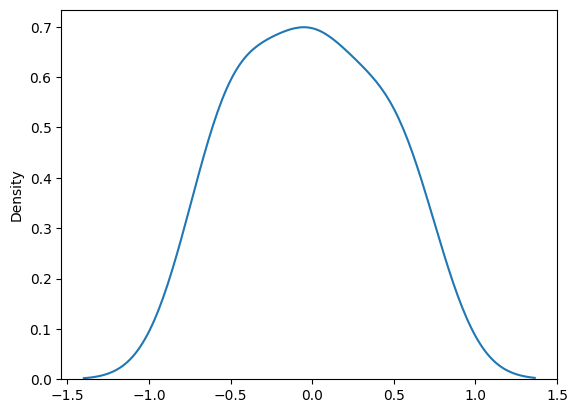

In [ ]:
import seaborn as sns
sns.kdeplot(weights[:,3])

In [ ]:
# 13 X 16 --> 2D --> reshape 1d(-1) --> 208


In [ ]:
mydata = weights.reshape(-1)

In [ ]:
mydata

array([-0.09823292,  0.6262684 ,  0.58855736,  0.5674858 , -0.12389809,
       -0.62883323, -0.22797969, -0.6329051 , -0.46031582, -0.21512142,
        0.48781538, -0.3554799 ,  0.15361893, -0.29041645, -0.45996338,
        0.22838801,  0.63987076,  0.42911553, -0.5210026 ,  0.06177104,
        0.06925958,  0.04785883, -0.04723215,  0.2769519 , -0.44002718,
       -0.3684634 ,  0.39295137, -0.301424  ,  0.5642413 , -0.67132926,
       -0.0101313 , -0.40319827, -0.45945913,  0.31664646,  0.13668346,
       -0.49635702, -0.03279054,  0.4481939 , -0.08285433,  0.17271382,
        0.5212368 ,  0.37916434,  0.19879949,  0.4226879 ,  0.1706059 ,
       -0.5576115 ,  0.10479784,  0.12904269,  0.15697277, -0.21233192,
       -0.49439263, -0.10188895,  0.0134365 , -0.30792576,  0.37814033,
        0.1132741 ,  0.36853826, -0.59300923, -0.38510892,  0.1513238 ,
        0.5422312 ,  0.4308617 ,  0.07321352,  0.3809588 ,  0.48590446,
        0.18853915,  0.49389017, -0.43501297,  0.39264107,  0.63

<Axes: ylabel='Density'>

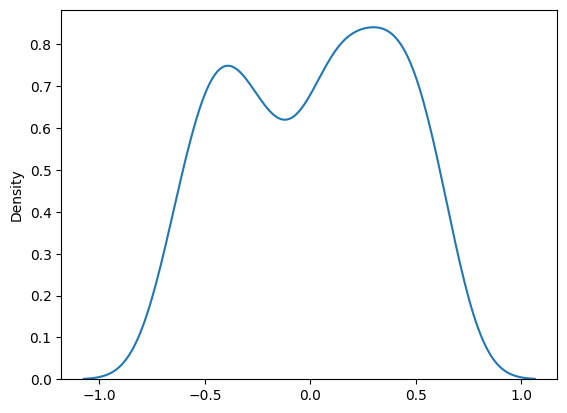

In [ ]:
import seaborn as sns
sns.kdeplot(mydata)

In [ ]:
...
# compile the keras model
model.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy'])

In [ ]:
# epoch --> when a complete dataset is used for the training, we say one epoch is completed
#       --> means, if you have 7500 train datapoints, so when all the 7500 train datapoint are utilised,
#       --> we say 1 epoch is completed.
#       --> since 30% is given to validation, we are left with only 5250 datapoints
#       --> if epoch is 50, means same dataset has to be repeated 50 times for training purpose
# validation_split(0.30) --> 30% of training data will be used for validation purpose.
#                        --> means, 30% of 7500 training data will goto validation dataset
#                        --> means, 2250 data point for validation data
# batch_size --> Group of datapoints which are forward propogated into the network is called batch size.
#            --> since bach size is 32, means 32 datapoints will be taken in a container and this container
#            --> is called as batch.
#            --> since we are having 5250 training datapoints, the total number of batch required to
#            --> complete one epoch will be 165


In [ ]:
# fit the keras model on the dataset
model_history=model.fit(X_train, y_train, epochs=50,validation_split=0.30, batch_size=32)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7021 - loss: 0.6141 - val_accuracy: 0.8067 - val_loss: 0.4608
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7884 - loss: 0.4671 - val_accuracy: 0.8124 - val_loss: 0.4289
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8124 - loss: 0.4260 - val_accuracy: 0.8204 - val_loss: 0.4142
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8072 - loss: 0.4283 - val_accuracy: 0.8271 - val_loss: 0.4037
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8230 - loss: 0.4100 - val_accuracy: 0.8391 - val_loss: 0.3930
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8163 - loss: 0.4171 - val_accuracy: 0.8480 - val_loss: 0.3847
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8273 - loss: 0.4104 - val_accuracy: 0.8493 - val_loss: 0.3742
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8275 - loss: 0.4010 - val_accuracy: 0

In [ ]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
print(model_history.history['val_loss'])

[0.4607868790626526, 0.42894724011421204, 0.4142081141471863, 0.40369313955307007, 0.39302122592926025, 0.384671151638031, 0.37418419122695923, 0.36699405312538147, 0.3593965172767639, 0.3513943552970886, 0.3473866879940033, 0.3437795639038086, 0.3407948315143585, 0.339981347322464, 0.3373534083366394, 0.340788871049881, 0.3369946777820587, 0.3372002840042114, 0.3354129195213318, 0.33518001437187195, 0.3347742557525635, 0.3343241512775421, 0.3329141438007355, 0.3355557322502136, 0.33228984475135803, 0.33437421917915344, 0.33425959944725037, 0.33091995120048523, 0.32967203855514526, 0.3298031687736511, 0.3311040699481964, 0.33058086037635803, 0.3326058089733124, 0.33243781328201294, 0.33207112550735474, 0.33233290910720825, 0.3330856263637543, 0.3330864906311035, 0.33276230096817017, 0.33162635564804077, 0.33511295914649963, 0.3373645842075348, 0.3346024751663208, 0.33464866876602173, 0.3341101109981537, 0.3341166377067566, 0.3366619348526001, 0.3372477889060974, 0.335725337266922, 0.33

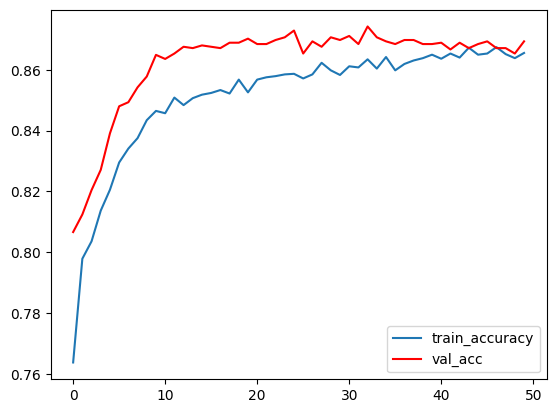

In [ ]:
import matplotlib.pyplot as plt
plt.plot(model_history.history['accuracy'],label='train_accuracy')
plt.plot(model_history.history['val_accuracy'],color='red',label='val_acc')
plt.legend()


In [ ]:
len(X_test)

2500

In [ ]:
print(y_test)

9957    0
1687    0
2116    0
231     0
2780    0
       ..
8514    0
5190    0
6766    1
347     0
6961    0
Name: Exited, Length: 2500, dtype: int64


In [ ]:
test_pred = model.predict(X_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [ ]:
test_pred = [1 if num > 0.5 else 0 for num in test_pred.reshape(-1)]

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,test_pred)

0.8572

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)


In [ ]:
print(y_pred)

In [ ]:
y_test

In [ ]:

y_pred

In [ ]:
y_pred.reshape(-1)

In [ ]:
mypred = [1 if prediction > 0.5 else 0 for prediction in y_pred.reshape(-1)]
print(mypred)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,test_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      2022
           1       0.67      0.49      0.57       478

    accuracy                           0.86      2500
   macro avg       0.78      0.72      0.74      2500
weighted avg       0.85      0.86      0.85      2500



In [ ]:
abc

In [ ]:
## < 0.5 = 0
## >= 0.5 = 1

y_prediction = np.array([1 if i >= 0.5 else 0 for i in y_pred.reshape(2500,)])

In [ ]:
accuracy_score(y_test,abc)

In [ ]:
model.evaluate(X_test,y_test)

In [ ]:
...
# evaluate the keras model
accuracy = model.evaluate(X_test, y_test)
accuracy

In [ ]:
# list all data in history
print(model_history.history.keys())

In [ ]:
model_history.history

In [ ]:
# summarize history for accuracy
import matplotlib.pyplot as plt
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.show()

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
#Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

In [ ]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score